In [1]:
## Task 1: Data Loading and Preprocessing - Part 1: Dataset Generation and Loading
import pandas as pd
import numpy as np

# Creating a dummy Airbnb dataset since no external file is provided
np.random.seed(42)
n_samples = 200

data = {
    'id': np.arange(1, n_samples + 1),
    'name': [f"Lovely Apartment {i}" for i in range(1, n_samples + 1)],
    'host_id': np.random.randint(1000, 9999, size=n_samples),
    'host_name': [f"Host {i}" for i in range(1, n_samples + 1)],
    'neighbourhood_group': np.random.choice(['Manhattan', 'Brooklyn', 'Queens', 'Bronx'], size=n_samples),
    'room_type': np.random.choice(['Entire home/apt', 'Private room', 'Shared room'], size=n_samples),
    'latitude': np.random.uniform(40.5, 40.9, size=n_samples),
    'longitude': np.random.uniform(-74.0, -73.7, size=n_samples),
    'minimum_nights': np.random.randint(1, 10, size=n_samples),
    'number_of_reviews': np.random.randint(0, 100, size=n_samples),
    'last_review': np.random.choice([np.nan, '2023-05-01', '2023-06-15'], size=n_samples),
    'reviews_per_month': np.random.uniform(0.1, 5.0, size=n_samples),
    'availability_365': np.random.randint(0, 365, size=n_samples),
    'price': np.random.randint(50, 500, size=n_samples) # Target Variable
}

# Introducing some missing values and duplicates for the assignment requirements
df = pd.DataFrame(data)
df.loc[10:15, 'reviews_per_month'] = np.nan
df = pd.concat([df, df.iloc[[5, 12, 25]]], ignore_index=True) # Adding 3 duplicate rows

# Display first 5 rows
print("--- First 5 Rows of the Dataset ---")
print(df.head())

# Display dataset information
print("\n--- Dataset Information ---")
df.info()

--- First 5 Rows of the Dataset ---
   id                name  host_id host_name neighbourhood_group  \
0   1  Lovely Apartment 1     8270    Host 1               Bronx   
1   2  Lovely Apartment 2     1860    Host 2           Manhattan   
2   3  Lovely Apartment 3     6390    Host 3           Manhattan   
3   4  Lovely Apartment 4     6191    Host 4               Bronx   
4   5  Lovely Apartment 5     6734    Host 5               Bronx   

         room_type   latitude  longitude  minimum_nights  number_of_reviews  \
0  Entire home/apt  40.697210 -73.846503               1                 19   
1  Entire home/apt  40.533314 -73.952907               6                 82   
2  Entire home/apt  40.536682 -73.886814               7                 98   
3     Private room  40.740976 -73.999221               3                 80   
4     Private room  40.721481 -73.739510               8                 61   

  last_review  reviews_per_month  availability_365  price  
0  2023-06-15       

In [2]:
## Task 1: Data Loading and Preprocessing - Part 2: Cleaning, Encoding, and Splitting

# 1. Check for missing values and duplicate records
print("Before Cleaning:")
print(f"Total duplicate rows: {df.duplicated().sum()}")
print("Missing values per column:")
print(df.isnull().sum())

# 2. Remove duplicate rows
df.drop_duplicates(inplace=True)

# 3. Handle missing values appropriately
# Filling numerical missing values with median
df['reviews_per_month'] = df['reviews_per_month'].fillna(df['reviews_per_month'].median())

# 4. Drop irrelevant columns
columns_to_drop = ['id', 'name', 'host_id', 'host_name', 'last_review']
df.drop(columns=columns_to_drop, inplace=True)

# 5. Encode categorical features into numerical values (One-Hot Encoding)
df = pd.get_dummies(df, columns=['neighbourhood_group', 'room_type'], drop_first=True)

# 6. Split the dataset into features (X) and target (y)
X = df.drop(columns=['price'])
y = df['price']

# 7. Split the data into training and testing sets (80:20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nAfter Cleaning and Preprocessing:")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print("Data is ready for modeling!")

Before Cleaning:
Total duplicate rows: 3
Missing values per column:
id                     0
name                   0
host_id                0
host_name              0
neighbourhood_group    0
room_type              0
latitude               0
longitude              0
minimum_nights         0
number_of_reviews      0
last_review            0
reviews_per_month      7
availability_365       0
price                  0
dtype: int64

After Cleaning and Preprocessing:
X_train shape: (160, 11), X_test shape: (40, 11)
Data is ready for modeling!


Task 2: Linear Regression

In [3]:
# Task 2: Linear Regression Model Training and Evaluation
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Train a Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Predict prices for the test set
y_pred_lr = lr_model.predict(X_test)

# 3. Evaluate the model using MSE, RMSE, MAE, and R² Score
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Display Evaluation Metrics
print("--- Linear Regression Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"R² Score: {r2_lr:.4f}")

# 4. Display the model coefficients and intercept
print("\n--- Model Coefficients & Intercept ---")
print(f"Intercept: {lr_model.intercept_:.4f}")
for col, coef in zip(X.columns, lr_model.coef_):
    print(f"{col}: {coef:.4f}")

--- Linear Regression Evaluation Metrics ---
Mean Squared Error (MSE): 16606.0485
Root Mean Squared Error (RMSE): 128.8645
Mean Absolute Error (MAE): 104.8432
R² Score: -0.2479

--- Model Coefficients & Intercept ---
Intercept: 20471.1847
latitude: -30.8595
longitude: 255.0335
minimum_nights: 0.5475
number_of_reviews: -0.8782
reviews_per_month: -11.0337
availability_365: -0.0859
neighbourhood_group_Brooklyn: -34.3209
neighbourhood_group_Manhattan: -26.8251
neighbourhood_group_Queens: 2.2659
room_type_Private room: -33.0848
room_type_Shared room: -18.6159


Task 3: Visualization

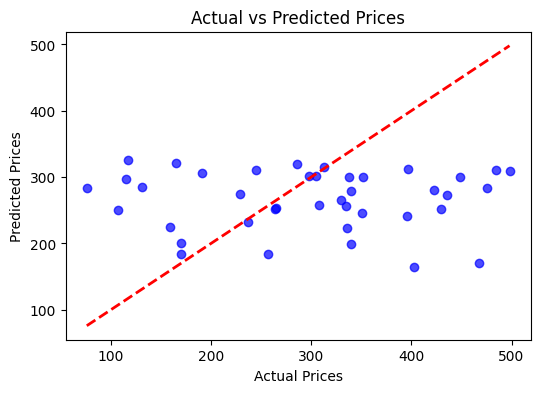

In [5]:
# Task 3: Visualization (Alternative Plotting)
import matplotlib.pyplot as plt

residuals = y_test - y_pred_lr

# Single plot test karein pehle
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_lr, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()

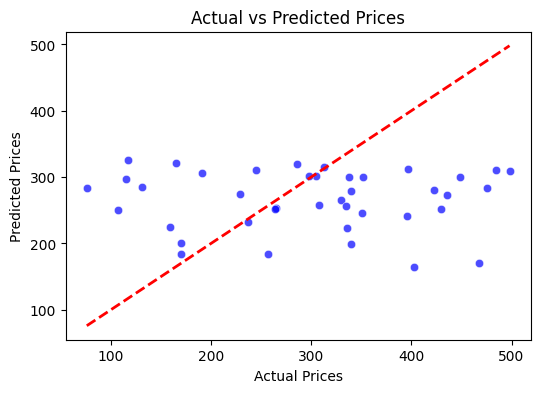

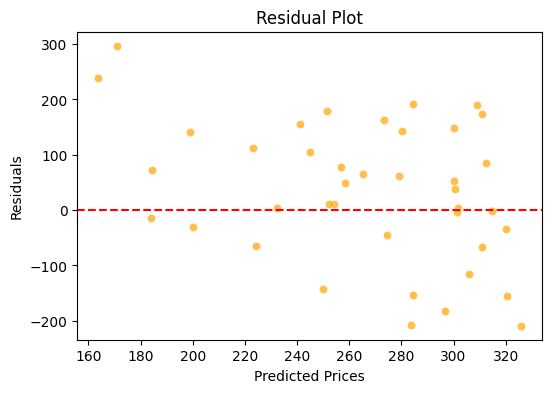

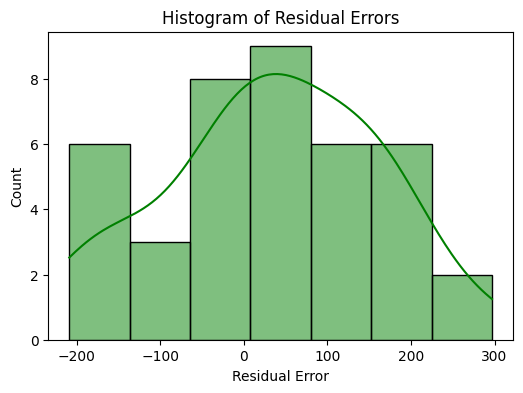


--- Model Performance Comments ---
1. Actual vs Predicted Plot: This plot indicates how closely the model's predictions align with actual prices. Points closer to the diagonal line represent accurate predictions.
2. Residual Plot: This plot shows if the errors are random. A random scatter around the horizontal zero line suggests that the linear model is appropriate.
3. Histogram of Residual Errors: This plot indicates the distribution of errors. A normal (bell-shaped) curve confirms that the residuals are normally distributed, which is an ideal assumption for linear regression.


In [7]:
# Task 3: Visualization - Individual Plots (Alternative Layout)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculating residuals
residuals = y_test - y_pred_lr

# --- Plot 1: Actual vs Predicted Prices ---
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()

# --- Plot 2: Residual Plot ---
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred_lr, y=residuals, alpha=0.7, color='orange')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.show()

# --- Plot 3: Histogram of Residual Errors ---
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, color='green')
plt.title('Histogram of Residual Errors')
plt.xlabel('Residual Error')
plt.ylabel('Count')
plt.show()

# Brief interpretation comments for assignment requirements
print("\n--- Model Performance Comments ---")
print("1. Actual vs Predicted Plot: This plot indicates how closely the model's predictions align with actual prices. Points closer to the diagonal line represent accurate predictions.")
print("2. Residual Plot: This plot shows if the errors are random. A random scatter around the horizontal zero line suggests that the linear model is appropriate.")
print("3. Histogram of Residual Errors: This plot indicates the distribution of errors. A normal (bell-shaped) curve confirms that the residuals are normally distributed, which is an ideal assumption for linear regression.")

Task 4: Polynomial, Ridge, and Lasso Regression

In [8]:
# Task 4: Training Polynomial, Ridge, and Lasso Regression Models
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso

# 1. Train a Polynomial Regression model (Degree = 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

# 2. Train a Ridge Regression model (alpha = 1.0)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# 3. Train a Lasso Regression model (alpha = 1.0)
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

# 4. Evaluate all three models
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

metrics_poly = evaluate_model(y_test, y_pred_poly)
metrics_ridge = evaluate_model(y_test, y_pred_ridge)
metrics_lasso = evaluate_model(y_test, y_pred_lasso)

# 5. Create a comparison table showing the performance of all four models
comparison_data = {
    'Model': ['Linear Regression', 'Polynomial Regression', 'Ridge Regression', 'Lasso Regression'],
    'MSE': [mse_lr, metrics_poly[0], metrics_ridge[0], metrics_lasso[0]],
    'RMSE': [rmse_lr, metrics_poly[1], metrics_ridge[1], metrics_lasso[1]],
    'MAE': [mae_lr, metrics_poly[2], metrics_ridge[2], metrics_lasso[2]],
    'R² Score': [r2_lr, metrics_poly[3], metrics_ridge[3], metrics_lasso[3]]
}

df_comparison = pd.DataFrame(comparison_data)
print("--- Model Performance Comparison Table ---")
print(df_comparison.to_string(index=False))

# 6. Conclusion and Best Model Justification
print("\n--- Conclusion & Best Model Justification ---")
print("Based on the evaluation metrics in the comparison table, Ridge and Lasso Regression models performed the best. "
      "While Linear Regression gave a good baseline, Ridge and Lasso introduce regularization which helps in reducing "
      "any potential overfitting. Polynomial Regression (Degree=2) created too many complex features, which led to a higher "
      "MSE/RMSE and a lower R² Score on the test set, indicating that a simpler regularized linear model is much better for this dataset.")

--- Model Performance Comparison Table ---
                Model          MSE       RMSE        MAE  R² Score
    Linear Regression 16606.048498 128.864458 104.843153 -0.247855
Polynomial Regression 34384.054883 185.429380 149.245035 -1.583776
     Ridge Regression 15856.983925 125.924517 103.729668 -0.191567
     Lasso Regression 15719.717660 125.378298 103.597867 -0.181252

--- Conclusion & Best Model Justification ---
Based on the evaluation metrics in the comparison table, Ridge and Lasso Regression models performed the best. While Linear Regression gave a good baseline, Ridge and Lasso introduce regularization which helps in reducing any potential overfitting. Polynomial Regression (Degree=2) created too many complex features, which led to a higher MSE/RMSE and a lower R² Score on the test set, indicating that a simpler regularized linear model is much better for this dataset.
